In [1]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('Wholesale.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
#I am Taking Grocery and Milk as Feature because dusra aur bhi lenge to mera comoutationally heavy ban ajyega whcih we will not do as of now


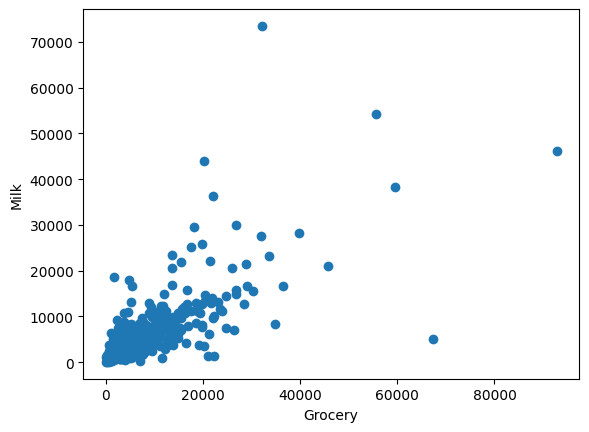

In [6]:
x=df['Grocery']
y=df['Milk']

plt.scatter(x,y)
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

In [7]:
#Going by the definition of density none of these observations will have any type of observation within those radious

#The very far would be our outliers and the closest one would be in clusters
#Anywhere where you are using Distance based fucntion , waha Scaling is very more Important
#so we need to scale the data
#qki scale krne se bahut jyada difference dikhta hai apne ko


In [8]:
df=df[['Grocery','Milk']]
std_scaler=StandardScaler()
df_std=std_scaler.fit_transform(df)

In [10]:
dbsc=DBSCAN(eps=.5,min_samples=15).fit(df_std)

In [12]:
labels=dbsc.labels_

In [13]:
core_samples=np.zeros_like(labels,dtype=bool)
core_samples[dbsc.core_sample_indices_]=True

In [14]:
out_df=df.copy()
out_df['label']=dbsc.labels_

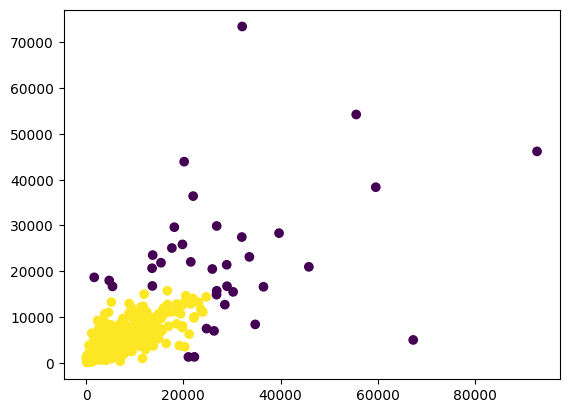

In [15]:
plt.scatter(out_df['Grocery'],out_df['Milk'],c=out_df['label'])

In [16]:
#As i said just a while ago like, all tese formed as 1 cluster with very high density
#and rest of them is formed as outliers

#Why??
#We defined the minimum sample in Boundary Reason should be atleast 15

#How do we know?


In [17]:
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0, -1,  0,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
       -1, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [18]:
#like previously in K means or any type of clustering , you labels would be 0,1,2,3 etc
#but yaha pe +ve and -1 hi hota
#where the -1 is outliers


#so don't think by just watching at point that they are outliers so hume wo labels dekhna padega inorder to know that the one which haas -1 as labels is actually as outliers


In [19]:
#This can be very handly if we are performing anamoly detection

In [21]:
from sklearn.cluster import KMeans
k=2 ##arbitrary value
kmeans=KMeans(n_clusters=k)
y=kmeans.fit_predict(df_std)

In [22]:
clusters=df.copy()
clusters['label']=y
clusters

,Grocery,Milk,label
0,7561,9656,1
1,9568,9810,1
2,7684,8808,1
3,4221,1196,1
4,7198,5410,1
...,...,...,...
435,16027,12051,1
436,764,1431,1
437,30243,15488,0
438,2232,1981,1


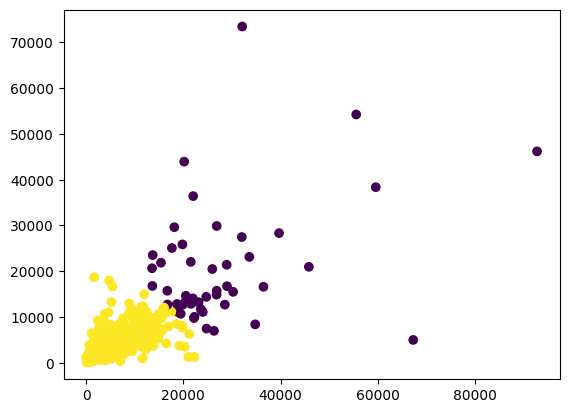

In [23]:
plt.scatter(clusters['Grocery'],clusters['Milk'],c=clusters['label'])

In [24]:
#Look at what K means have done it has formed centroid and calculate the distance
#it started with 2 centroid and then converged
#it clubbed all those observations that are having low grocery and milk usage and the rest as 1 clusters
#what is the main goal??



In [25]:
#if it in not scaled data then
#suppose 1 is age and other is salary, age is 30 and salary is 4 lakhs
#and if you try to find euclidean distance between it , what kind of unit it will be
#it'll be just arbitrary value so i can't define units


#here it is on scaled data so we are gviing epsilon as 0.5


In [26]:
#The beauty about data science is when you able to connect those input and dost and what your function is doing then it'll be very best
#This will be very helpful in terms of interview